In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('output/cluster_results/paper_topics.csv')
df.head()

,paper_id,country,year,country_code,topic,topic_prob
0,WOS:A1990EQ23400008,Canada,1990,Canada,53,0.957332
1,WOS:A1990EQ34700002,United States,1990,US,14,0.964491
2,WOS:A1990DM80100011,Czech Republic,1990,Czech Republic,29,0.944935
3,WOS:A1990EF25500003,United States,1990,US,15,0.953150
4,WOS:A1990EW03700009,Czechia,1990,Czechia,8,0.965757


In [3]:
from collections import Counter

def jaccard_with_duplicates(list1, list2):
    c1 = Counter(list1)
    c2 = Counter(list2)
    
    keys = c1.keys() | c2.keys()
    inter = sum(min(c1[k], c2[k]) for k in keys)
    union = sum(max(c1[k], c2[k]) for k in keys)
    
    return inter / union if union else 0.0

In [4]:
year_china_lag_us = {}
for year in range(2010, 2026):
    china_df = df[df['year'] == year]
    china_df = china_df[china_df['country'] == 'China']
    print(f"Found {len(china_df)} papers for {year}")
    china_topics = china_df['topic'].tolist()
    lags = {}
    for lag in range(0, 10):
        if year - lag >= 2025:
            continue
        if year - lag < 2000:
            continue
        america_df = df[(df['year'] == year - lag) & (df['country'] == 'United States')]
        amer_topics = america_df['topic'].tolist()
        # 计算相似度
        jaccard = jaccard_with_duplicates(china_topics, amer_topics)
        lags[lag] = jaccard
    year_china_lag_us[year] = lags
        

Found 33 papers for 2010
Found 69 papers for 2011
Found 59 papers for 2012
Found 81 papers for 2013
Found 128 papers for 2014
Found 118 papers for 2015
Found 156 papers for 2016
Found 227 papers for 2017
Found 253 papers for 2018
Found 319 papers for 2019
Found 401 papers for 2020
Found 441 papers for 2021
Found 600 papers for 2022
Found 648 papers for 2023
Found 845 papers for 2024
Found 1031 papers for 2025


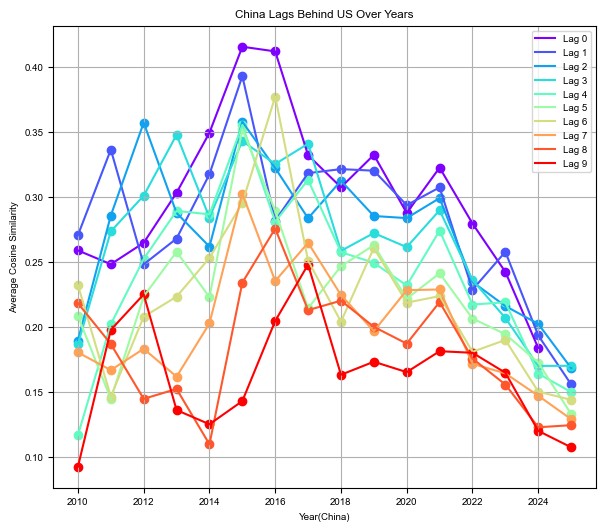

In [5]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

plt.rcParams['font.family'] = 'Arial'  # 设置英文字体为Arial
plt.rcParams.update({'font.size': 7})  # 设置全局字体为7号

data_china_lag_us = []
for year, lags in year_china_lag_us.items():
    for lag, value in lags.items():
        data_china_lag_us.append((lag, year, value))

df_lags = pd.DataFrame(data_china_lag_us, columns=['lag', 'year', 'value'])
unique_lags = df_lags['lag'].unique()
colors = cm.rainbow(np.linspace(0, 1, len(unique_lags)))

plt.figure(figsize=(7, 6))

for lag, color in zip(unique_lags, colors):
    subset = df_lags[df_lags['lag'] == lag]
    plt.plot(subset['year'], subset['value'], label=f'Lag {lag}', color=color)
    plt.scatter(subset['year'], subset['value'], color=color)

plt.xlabel('Year(China)')
plt.ylabel('Average Cosine Similarity')
plt.title('China Lags Behind US Over Years')
plt.legend(fontsize=7)
plt.grid(True)
plt.savefig('cosine_similarity_China_lags_behind_US_China_year-all.png')
plt.show()

In [6]:
year_us_lag_china = {}
for year in range(2010, 2026):
    america_df = df[df['year'] == year]
    america_df = america_df[america_df['country'] == 'United States']
    print(f"Found {len(america_df)} papers for {year}")
    america_topics = america_df['topic'].tolist()
    lags = {}
    for lag in range(0, 10):
        if year - lag >= 2025:
            continue
        if year - lag < 2000:
            continue
        china_df = df[(df['year'] == year - lag) & (df['country'] == 'China')]
        china_topics = china_df['topic'].tolist()
        # 计算相似度
        jaccard = jaccard_with_duplicates(america_topics, china_topics)
        lags[lag] = jaccard
    year_us_lag_china[year] = lags

Found 74 papers for 2010
Found 107 papers for 2011
Found 113 papers for 2012
Found 121 papers for 2013
Found 123 papers for 2014
Found 117 papers for 2015
Found 125 papers for 2016
Found 154 papers for 2017
Found 151 papers for 2018
Found 154 papers for 2019
Found 163 papers for 2020
Found 174 papers for 2021
Found 201 papers for 2022
Found 198 papers for 2023
Found 186 papers for 2024
Found 197 papers for 2025


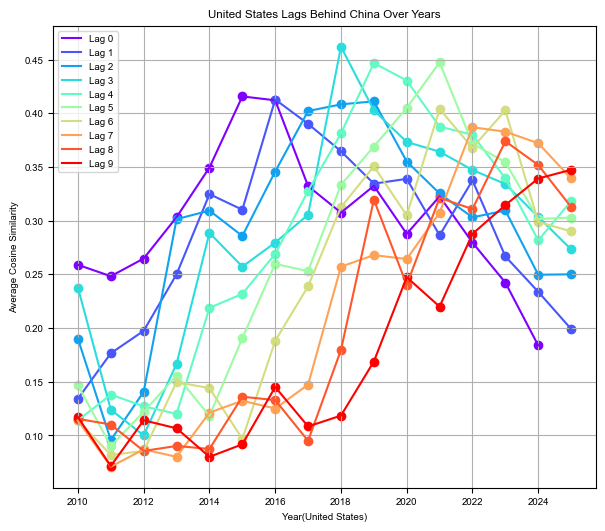

In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

plt.rcParams['font.family'] = 'Arial'  # 设置英文字体为Arial
plt.rcParams.update({'font.size': 7})  # 设置全局字体为7号

data_us_lag_china = []
for year, lags in year_us_lag_china.items():
    for lag, value in lags.items():
        data_us_lag_china.append((lag, year, value))

df_lags = pd.DataFrame(data_us_lag_china, columns=['lag', 'year', 'value'])
unique_lags = df_lags['lag'].unique()
colors = cm.rainbow(np.linspace(0, 1, len(unique_lags)))

plt.figure(figsize=(7, 6))

for lag, color in zip(unique_lags, colors):
    subset = df_lags[df_lags['lag'] == lag]
    plt.plot(subset['year'], subset['value'], label=f'Lag {lag}', color=color)
    plt.scatter(subset['year'], subset['value'], color=color)

plt.xlabel('Year(United States)')
plt.ylabel('Average Cosine Similarity')
plt.title('United States Lags Behind China Over Years')
plt.legend(fontsize=7)
plt.grid(True)
plt.savefig('cosine_similarity_US_lags_behind_China_United_States_year-all.png')
plt.show()

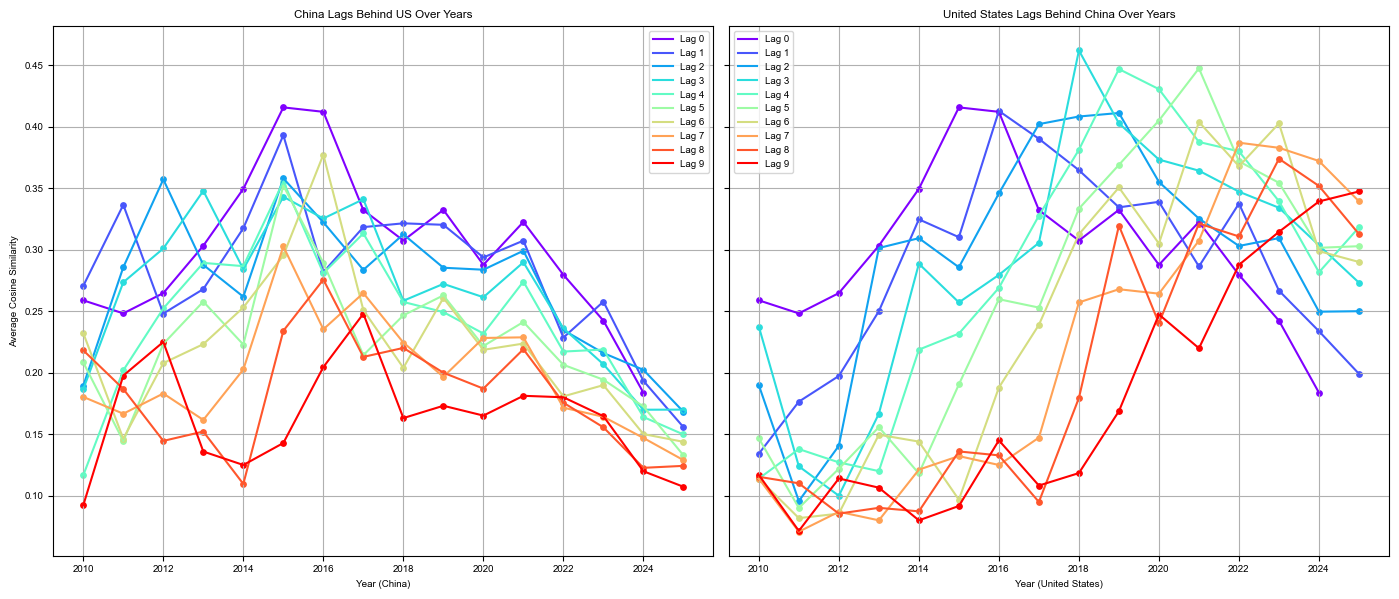

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

plt.rcParams['font.family'] = 'Arial'
plt.rcParams.update({'font.size': 7})

# ===== 处理 China lags behind US 数据 =====
data_china_lag_us = []
for year, lags in year_china_lag_us.items():
    for lag, value in lags.items():
        data_china_lag_us.append((lag, year, value))

df_china_lag_us = pd.DataFrame(data_china_lag_us, columns=['lag', 'year', 'value'])


# ===== 处理 US lags behind China 数据 =====
data_us_lag_china = []
for year, lags in year_us_lag_china.items():
    for lag, value in lags.items():
        data_us_lag_china.append((lag, year, value))

df_us_lag_china = pd.DataFrame(data_us_lag_china, columns=['lag', 'year', 'value'])


# ===== 为所有 lag 统一配色，保证两张图颜色一致 =====
all_lags = sorted(set(df_china_lag_us['lag']).union(set(df_us_lag_china['lag'])))
colors = cm.rainbow(np.linspace(0, 1, len(all_lags)))
lag_color_map = dict(zip(all_lags, colors))


# ===== 创建合并图 =====
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- 左图：China lags behind US ---
for lag in sorted(df_china_lag_us['lag'].unique()):
    subset = df_china_lag_us[df_china_lag_us['lag'] == lag].sort_values('year')
    axes[0].plot(
        subset['year'],
        subset['value'],
        label=f'Lag {lag}',
        color=lag_color_map[lag]
    )
    axes[0].scatter(
        subset['year'],
        subset['value'],
        color=lag_color_map[lag],
        s=15
    )

axes[0].set_xlabel('Year (China)')
axes[0].set_ylabel('Average Cosine Similarity')
axes[0].set_title('China Lags Behind US Over Years')
axes[0].grid(True)
axes[0].legend(fontsize=7)


# --- 右图：US lags behind China ---
for lag in sorted(df_us_lag_china['lag'].unique()):
    subset = df_us_lag_china[df_us_lag_china['lag'] == lag].sort_values('year')
    axes[1].plot(
        subset['year'],
        subset['value'],
        label=f'Lag {lag}',
        color=lag_color_map[lag]
    )
    axes[1].scatter(
        subset['year'],
        subset['value'],
        color=lag_color_map[lag],
        s=15
    )

axes[1].set_xlabel('Year (United States)')
axes[1].set_title('United States Lags Behind China Over Years')
axes[1].grid(True)
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig('cosine_similarity_combined.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
year_china_lag_japan = {}
for year in range(2010, 2026):
    china_df = df[df['year'] == year]
    china_df = china_df[china_df['country'] == 'China']
    print(f"Found {len(china_df)} papers for {year}")
    china_topics = china_df['topic'].tolist()
    lags = {}
    for lag in range(0, 10):
        if year - lag >= 2025:
            continue
        if year - lag < 2000:
            continue
        japan_df = df[(df['year'] == year - lag) & (df['country'] == 'Japan')]
        japan_topics = japan_df['topic'].tolist()
        # 计算相似度
        jaccard = jaccard_with_duplicates(china_topics, japan_topics)
        lags[lag] = jaccard
    year_china_lag_japan[year] = lags
        

Found 33 papers for 2010
Found 69 papers for 2011
Found 59 papers for 2012
Found 81 papers for 2013
Found 128 papers for 2014
Found 118 papers for 2015
Found 156 papers for 2016
Found 227 papers for 2017
Found 253 papers for 2018
Found 319 papers for 2019
Found 401 papers for 2020
Found 441 papers for 2021
Found 600 papers for 2022
Found 648 papers for 2023
Found 845 papers for 2024
Found 1031 papers for 2025


In [12]:
year_japan_lag_china = {}
for year in range(2010, 2026):
    japan_df = df[df['year'] == year]
    japan_df = japan_df[japan_df['country'] == 'Japan']
    print(f"Found {len(japan_df)} papers for {year}")
    japan_topics = japan_df['topic'].tolist()
    lags = {}
    for lag in range(0, 10):
        if year - lag >= 2025:
            continue
        if year - lag < 2000:
            continue
        china_df = df[(df['year'] == year - lag) & (df['country'] == 'China')]
        china_topics = china_df['topic'].tolist()
        # 计算相似度
        jaccard = jaccard_with_duplicates(japan_topics, china_topics)
        lags[lag] = jaccard
    year_japan_lag_china[year] = lags

Found 20 papers for 2010
Found 52 papers for 2011
Found 107 papers for 2012
Found 159 papers for 2013
Found 179 papers for 2014
Found 185 papers for 2015
Found 163 papers for 2016
Found 151 papers for 2017
Found 151 papers for 2018
Found 167 papers for 2019
Found 189 papers for 2020
Found 176 papers for 2021
Found 157 papers for 2022
Found 131 papers for 2023
Found 116 papers for 2024
Found 125 papers for 2025


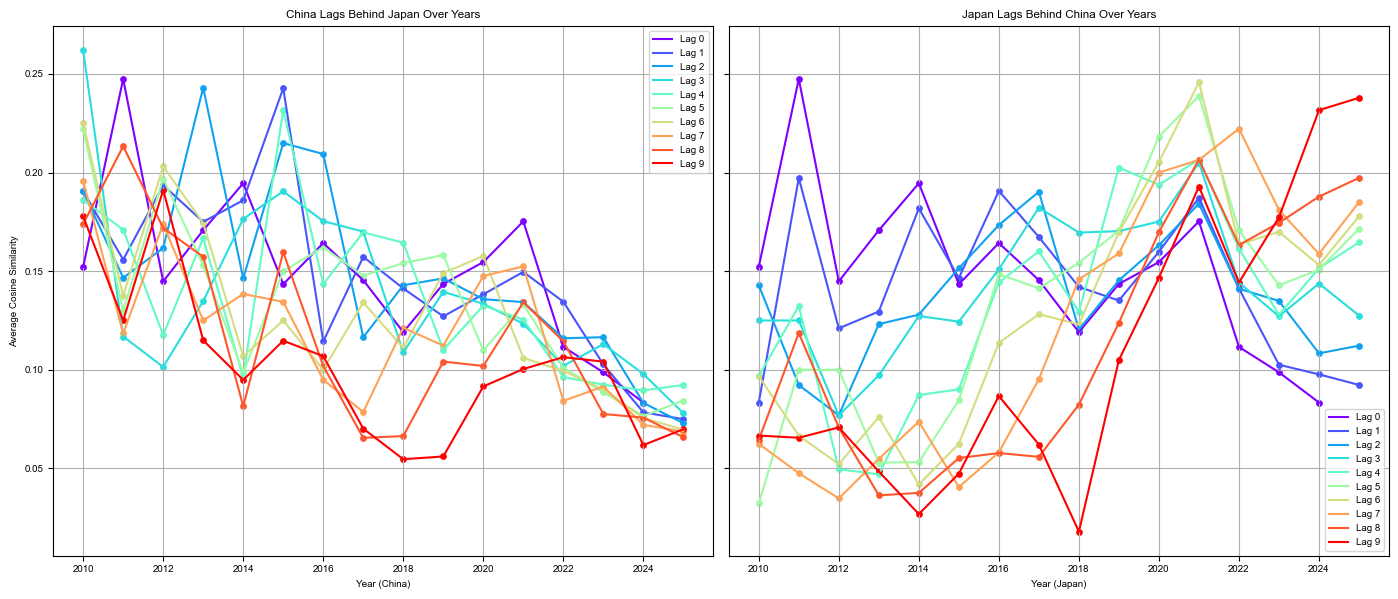

In [13]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

plt.rcParams['font.family'] = 'Arial'
plt.rcParams.update({'font.size': 7})

# ===== 处理 China lags behind Japan 数据 =====
data_china_lag_japan = []
for year, lags in year_china_lag_japan.items():
    for lag, value in lags.items():
        data_china_lag_japan.append((lag, year, value))

df_china_lag_japan = pd.DataFrame(data_china_lag_japan, columns=['lag', 'year', 'value'])


# ===== 处理 Japan lags behind China 数据 =====
data_japan_lag_china = []
for year, lags in year_japan_lag_china.items():
    for lag, value in lags.items():
        data_japan_lag_china.append((lag, year, value))

df_japan_lag_china = pd.DataFrame(data_japan_lag_china, columns=['lag', 'year', 'value'])


# ===== 为所有 lag 统一配色，保证两张图颜色一致 =====
all_lags = sorted(set(df_china_lag_japan['lag']).union(set(df_japan_lag_china['lag'])))
colors = cm.rainbow(np.linspace(0, 1, len(all_lags)))
lag_color_map = dict(zip(all_lags, colors))


# ===== 创建合并图 =====
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- 左图：China lags behind Japan ---
for lag in sorted(df_china_lag_japan['lag'].unique()):
    subset = df_china_lag_japan[df_china_lag_japan['lag'] == lag].sort_values('year')
    axes[0].plot(
        subset['year'],
        subset['value'],
        label=f'Lag {lag}',
        color=lag_color_map[lag]
    )
    axes[0].scatter(
        subset['year'],
        subset['value'],
        color=lag_color_map[lag],
        s=15
    )

axes[0].set_xlabel('Year (China)')
axes[0].set_ylabel('Average Cosine Similarity')
axes[0].set_title('China Lags Behind Japan Over Years')
axes[0].grid(True)
axes[0].legend(fontsize=7)


# --- 右图：Japan lags behind China ---
for lag in sorted(df_japan_lag_china['lag'].unique()):
    subset = df_japan_lag_china[df_japan_lag_china['lag'] == lag].sort_values('year')
    axes[1].plot(
        subset['year'],
        subset['value'],
        label=f'Lag {lag}',
        color=lag_color_map[lag]
    )
    axes[1].scatter(
        subset['year'],
        subset['value'],
        color=lag_color_map[lag],
        s=15
    )

axes[1].set_xlabel('Year (Japan)')
axes[1].set_title('Japan Lags Behind China Over Years')
axes[1].grid(True)
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig('cosine_similarity_combined.png', dpi=300, bbox_inches='tight')
plt.show()